# Compare performance with different settings of threads number

In [1]:
import os
import time
import random
import matplotlib.pyplot as plt
import numpy as np
import subprocess

In [2]:
import platform
import multiprocessing

print(platform.platform())
print(platform.python_version())
print('CPU cores count:', multiprocessing.cpu_count())

macOS-13.5-x86_64-i386-64bit
3.11.5
CPU cores count: 4


In [3]:
# Create 10000 files with 256 KB data
os.makedirs('/tmp/imohash-test', exist_ok=True)
for i in range(10000):        
    with open(f'/tmp/imohash-test/file_{i}.txt', 'wb') as f:
        f.write(os.urandom(256 * 1024))  # 256 KB

## Testing & metrics collecting

In [4]:
file_paths = [f'/tmp/imohash-test/file_{i}.txt' for i in range(10000)]

# Test with different sample sizes (files count)
sample_sizes = [100, 500, 1000, 2000, 5000, 8000, 10000]
threads_count_list = [1, 2, 4, 8, 16, 32, 64]
colors = ["#FF0000", "#00AA00", "#0000FF", "#FFA500", "#800080", "#008080", "#FF00FF"]

result = {}
for threads_count in threads_count_list:
    time_ = []
    result[threads_count] = time_
    
    for size in sample_sizes:
        sample = file_paths[:size]
        start = time.time()
        subprocess.run(["imohash", f"--threads={threads_count}"] + sample, stdout=subprocess.DEVNULL)
        result[threads_count].append(time.time() - start)

## Graphics rendering

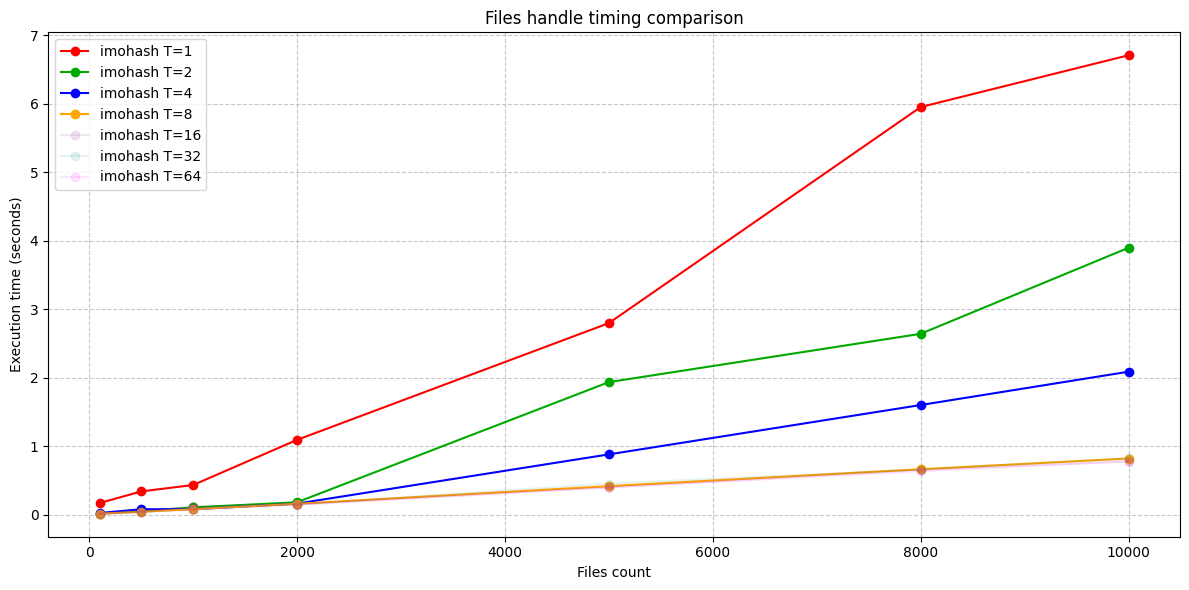

In [5]:
plt.figure(figsize=(12, 6))

for i, (threads_count, time_) in enumerate(result.items()):
    alpha = 1
    if threads_count > 8: 
        alpha = 0.1
    
    plt.plot(sample_sizes, time_, label=f'imohash T={threads_count}', marker='o', color=colors[i], alpha=alpha)

# graphic configuration
plt.title(f'Files handle timing comparison')
plt.xlabel('Files count')
plt.ylabel('Execution time (seconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
    
# save graphic
plt.savefig(f'docs/_static/performance_comparison.svg', dpi=300)
plt.show()

## Additional analyze (time per operation)

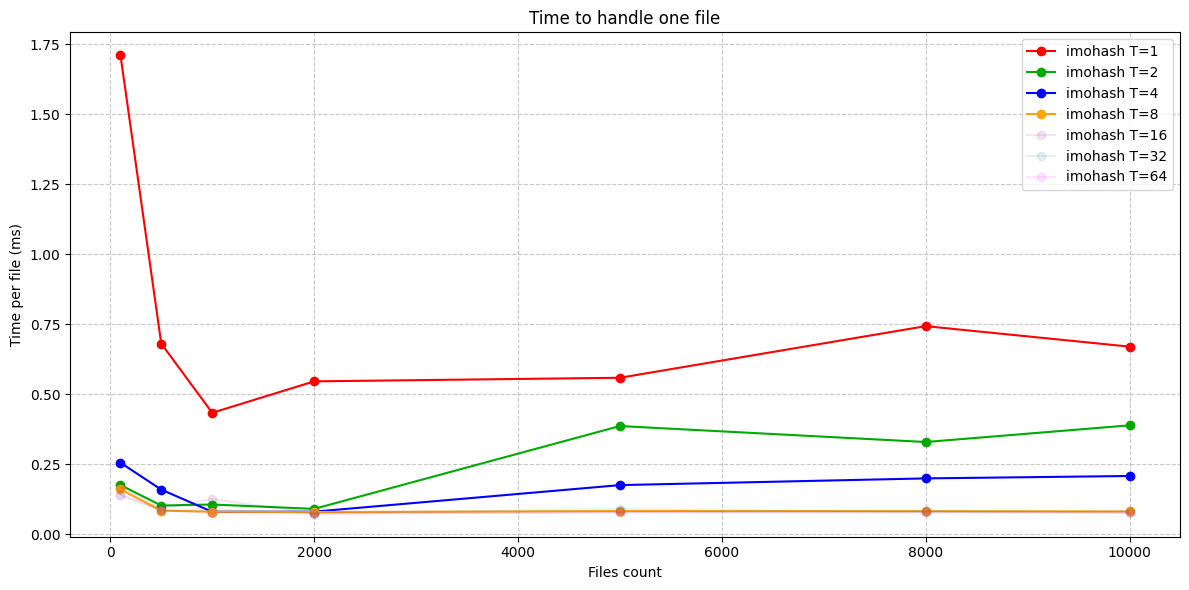

In [6]:
plt.figure(figsize=(12, 6))
for i, (threads_count, time_) in enumerate(result.items()):
    # Calculate time per one operation (file)
    time_per_op = np.array(time_) / np.array(sample_sizes)

    alpha = 1
    if threads_count > 8: 
        alpha = 0.1
    
    plt.plot(sample_sizes, time_per_op * 1000, label=f'imohash T={threads_count}', marker='o', color=colors[i], alpha=alpha)

plt.title(f'Time to handle one file')
plt.xlabel('Files count')
plt.ylabel('Time per file (ms)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig(f'docs/_static/time_per_operation.svg', dpi=300)
plt.show()

## Cleanup test files (optional)

In [ ]:
# Remove test files
import shutil
shutil.rmtree('/tmp/imohash-test')